In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar y preparar datos (un valor por OSA + DÍA)
df = pd.read_parquet("../data/processed/feature_dataset.parquet")


In [ ]:

# construir DF diario 
df["date"] = pd.to_datetime(df["timestamp"]).dt.date
agg_dict = {
    "distance_km":   "sum",            # ←  nuestra y
    "velocity_kmh":  "mean",
    "bearing_change":"mean",
    "acceleration_kmph2":"mean",
    "daylight_hours":"mean",
    "season":        "first",
    "movement_pattern":"first",
    "AvgLatitude":   "first",
    "AvgLongitude":  "first"
}
daily = (df
         .groupby(["UniqueAnimalID","date"])
         .agg(agg_dict)
         .rename(columns={"distance_km":"distance_per_day_real"})
         .reset_index())

# dummies para categóricas
daily = pd.get_dummies(daily, columns=["season","movement_pattern"], drop_first=True)


In [6]:
daily.columns

Index(['UniqueAnimalID', 'date', 'distance_per_day_real', 'velocity_kmh',
       'bearing_change', 'acceleration_kmph2', 'daylight_hours', 'AvgLatitude',
       'AvgLongitude', 'season_transicion', 'season_verano',
       'movement_pattern_estacionario'],
      dtype='object')

In [ ]:

# Definir X e y
target  = "distance_per_day_real"
drop_id = ["UniqueAnimalID", "date"]
X = daily.drop(columns=[target]+drop_id)
y = daily[target]

# Train / test + escalado (para RF no es crítico, pero ayuda en otros)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
scaler  = StandardScaler().fit(X_train)
X_train_scaled, X_test_scaled = scaler.transform(X_train), scaler.transform(X_test)

# Random Forest con búsqueda de hiper-parámetros
rf = RandomForestRegressor(random_state=10)
param_grid = {
    "n_estimators":[200,400],
    "max_depth":[None,10,20],
    "min_samples_leaf":[1,2,5]
}
grid = GridSearchCV(rf, param_grid, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_

# Evaluación
def metrics(y_true,y_pred):
    return (mean_absolute_error(y_true,y_pred),
            np.sqrt(mean_squared_error(y_true,y_pred)),
            r2_score(y_true,y_pred))

mae_tr, rmse_tr, r2_tr = metrics(y_train, best_rf.predict(X_train))
mae_te, rmse_te, r2_te = metrics(y_test,  best_rf.predict(X_test))

print(f"RF  MAE={mae_te:.2f}  RMSE={rmse_te:.2f}  R²={r2_te:.3f}")

# Importancia de variables
imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6,4)); sns.barplot(x=imp.values, y=imp.index); plt.title("Feature importance"); plt.tight_layout()


In [2]:
print(f"RF  MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}  R²={r2_tr:.3f}")

RF  MAE=0.32  RMSE=3.47  R²=0.949


In [ ]:

# 08  Guardar modelo y scaler
with open("../models/rf_daily.pkl","wb") as f: pickle.dump(best_rf,f)
with open("../models/scale_daily.pkl","wb") as f: pickle.dump(scaler,f)


1era prueba:

RF  MAE=0.32  RMSE=3.47  R²=0.949

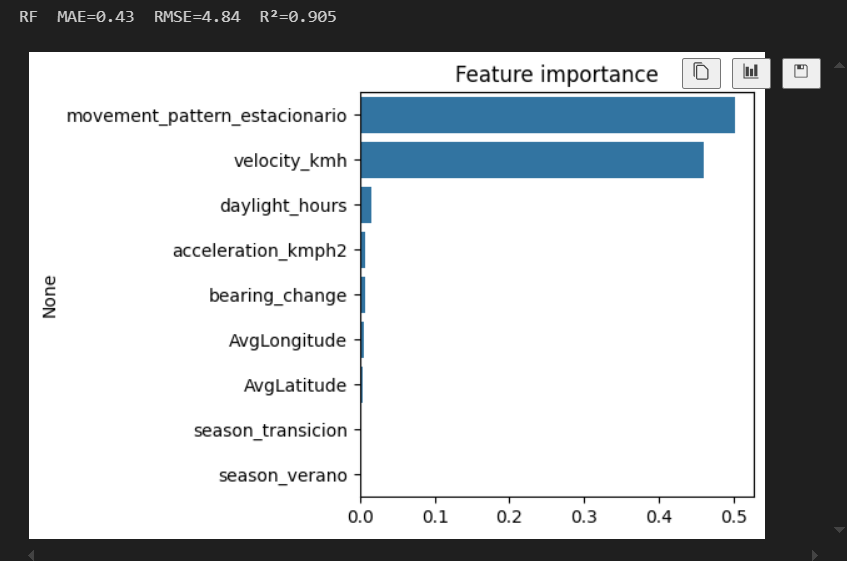

In [7]:
X.columns

Index(['velocity_kmh', 'bearing_change', 'acceleration_kmph2',
       'daylight_hours', 'AvgLatitude', 'AvgLongitude', 'season_transicion',
       'season_verano', 'movement_pattern_estacionario'],
      dtype='object')

Mi gozo en un pozo. Me acabo de dar cuenta de que _movement_pattern_ está calculado en base a _distance_per_day_real_ por eso corr altisimia, 

_____________________________________________________________________________

Cambio de estrategía: prescindo de la variable _movement_pattern_ y a ver que sale 

In [10]:
# Cargar datos ya diarios (distance_per_day_real presente)
df = pd.read_parquet("../data/processed/feature_dataset.parquet")

# Variables
target = "distance_per_day_real"

num_features = [
    "velocity_kmh", "bearing_change", "acceleration_kmph2",
    "daylight_hours", "AvgLatitude", "AvgLongitude"
]
cat_features = ["season"]           # SIN movement_pattern

# Dummies para season
df = pd.get_dummies(df, columns=cat_features, drop_first=True)

features = num_features + [c for c in df.columns if c.startswith("season_")]

df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=10
)

# Escalado para modelos lineales
scaler = StandardScaler().fit(X_train)
X_train_sc, X_test_sc = scaler.transform(X_train), scaler.transform(X_test)

# Definir modelos + grids
model_defs = {
    "Linear (scaled)": {
        "model": LinearRegression(),
        "Xtr": X_train_sc, "Xte": X_test_sc,
        "grid": {}
    },
    "Ridge (scaled)": {
        "model": Ridge(),
        "Xtr": X_train_sc, "Xte": X_test_sc,
        "grid": {"alpha": np.logspace(-3, 3, 20)}
    },
    "RandomForest": {
        "model": RandomForestRegressor(random_state=10),
        "Xtr": X_train, "Xte": X_test,            # sin escalado
        "grid": {
            "n_estimators": [200, 400],
            "max_depth": [None, 10, 20],
            "min_samples_leaf": [1, 2, 5]
        }
    }
}

results = []
best_model = None
best_r2    = -np.inf

for name, cfg in model_defs.items():
    if cfg["grid"]:
        search = GridSearchCV(cfg["model"], cfg["grid"],
                              cv=5, scoring="r2", n_jobs=-1)
        search.fit(cfg["Xtr"], y_train)
        model = search.best_estimator_
        cv_r2 = search.best_score_
    else:
        model = cfg["model"].fit(cfg["Xtr"], y_train)
        cv_r2 = cross_val_score(model, cfg["Xtr"], y_train,
                                cv=5, scoring="r2").mean()

    # Predicciones
    pred_tr = model.predict(cfg["Xtr"])
    pred_te = model.predict(cfg["Xte"])

    results.append({
        "Modelo": name,
        "MAE train": mean_absolute_error(y_train, pred_tr),
        "MAE test":  mean_absolute_error(y_test,  pred_te),
        "RMSE train": np.sqrt(mean_squared_error(y_train, pred_tr)),
        "RMSE test":  np.sqrt(mean_squared_error(y_test,  pred_te)),
        "R² train":  r2_score(y_train, pred_tr),
        "R² test":   r2_score(y_test,  pred_te),
        "CV R² (5-fold)": cv_r2
    })

    # Guardar el mejor según R² test
    if r2_score(y_test, pred_te) > best_r2:
        best_r2, best_model = r2_score(y_test, pred_te), model

#  Resultados
df_res = pd.DataFrame(results).sort_values("R² test", ascending=False)
print(df_res.to_string(index=False))

# 08  Guardar mejor modelo + scaler
with open("./models/best_reg_daily.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("./models/scale_reg_daily.pkl", "wb") as f:
    pickle.dump(scaler, f)


c:\Users\Ana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Ana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Ana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Ana\AppData\Local\Pr

         Modelo  MAE train  MAE test  RMSE train  RMSE test  R² train  R² test  CV R² (5-fold)
   RandomForest   4.704429  4.812572    9.418140   9.731049  0.622278 0.571356        0.569622
 Ridge (scaled)   5.020149  4.936194   10.851222  10.393691  0.498583 0.510991        0.499179
Linear (scaled)   5.020149  4.936194   10.851222  10.393691  0.498583 0.510991        0.499179


FileNotFoundError: [Errno 2] No such file or directory: './models/best_reg_daily.pkl'

In [11]:
with open("../models/best_reg_daily.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("../models/scale_reg_daily.pkl", "wb") as f:
    pickle.dump(scaler, f)

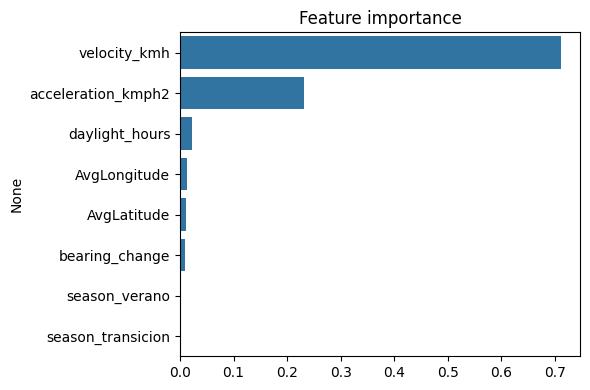

In [13]:
# 07  Importancia de variables
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6,4)); sns.barplot(x=imp.values, y=imp.index); plt.title("Feature importance"); plt.tight_layout()

In [15]:
imp.sort_values(ascending=False)

velocity_kmh          0.711442
acceleration_kmph2    0.231035
daylight_hours        0.022161
AvgLongitude          0.012116
AvgLatitude           0.012073
bearing_change        0.009316
season_verano         0.001612
season_transicion     0.000244
dtype: float64

I Prueba: LR + Ridge + RF

target = "distance_per_day_real"

num_features = [
    "velocity_kmh", "bearing_change", "acceleration_kmph2",
    "daylight_hours", "AvgLatitude", "AvgLongitude"
]

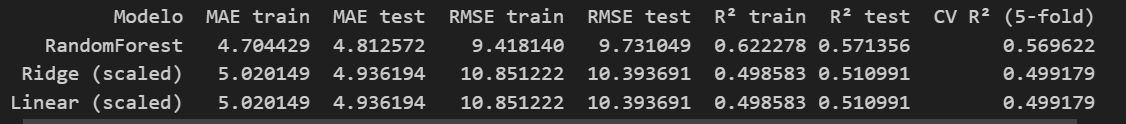

Modelo	MAE test	RMSE test	R² test	AUC-CV (5-fold)
Random Forest	4.81	9.73	0.57	0.57
Ridge (scaled)	4.94	10.39	0.51	0.50
Linear (scaled)	4.94	10.39	0.51	0.50

Un R² ≈ 0.57 significa que explicas el 57 % de la variabilidad diaria real.
En datos biológicos tan ruidosos es un resultado aceptable y defendible (muy por encima del azar).

In [12]:
df.distance_per_day_real.mean()

np.float64(21.77559637814792)

In [17]:
grid.best_estimator_

RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_estimators=200,
                      random_state=10)

In [18]:
X.columns

Index(['velocity_kmh', 'bearing_change', 'acceleration_kmph2',
       'daylight_hours', 'AvgLatitude', 'AvgLongitude', 'season_transicion',
       'season_verano'],
      dtype='object')